In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.utils import save_image
import os
import csv
import matplotlib.pyplot as plt
from torchsummary import summary
import matplotlib
# ====================
# Config
# ====================
latent_dim = 100
img_size = 28
channels = 1
batch_size = 64
epochs = 50
lr = 0.0002
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("images_gan", exist_ok=True)
loss_file_path = "simple_gan_losses.csv"

# ====================
# Data Loader
# ====================
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
dataloader = DataLoader(datasets.MNIST('.', train=True, download=True, transform=transform), batch_size=batch_size, shuffle=True)

# ====================
# Models
# ====================
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(nn.Linear(latent_dim, 128), nn.ReLU(True), nn.Linear(128, 256), nn.BatchNorm1d(256), nn.ReLU(True), nn.Linear(256, 512), nn.BatchNorm1d(512), nn.ReLU(True), nn.Linear(512, img_size * img_size), nn.Tanh())
    def forward(self, z):
        return self.model(z).view(z.size(0), 1, img_size, img_size)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(nn.Linear(img_size * img_size, 512), nn.LeakyReLU(0.2, True), nn.Linear(512, 256), nn.LeakyReLU(0.2, True), nn.Linear(256, 1), nn.Sigmoid())
    def forward(self, img):
        return self.model(img.view(img.size(0), -1))

# ====================
# Initialization
# ====================
generator = Generator().to(device)
discriminator = Discriminator().to(device)

In [8]:
# --- Print Generator Summary ---
# Input shape for the Generator is the noise vector
# --- Print Generator Summary ---
# Input shape is the 1D noise vector
print("------------------------------------------------------------")
print("                    Generator Summary")
print("------------------------------------------------------------")
summary(generator, (latent_dim,))

------------------------------------------------------------
                    Generator Summary
------------------------------------------------------------
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 784]                 --
|    └─Linear: 2-1                       [-1, 128]                 12,928
|    └─ReLU: 2-2                         [-1, 128]                 --
|    └─Linear: 2-3                       [-1, 256]                 33,024
|    └─BatchNorm1d: 2-4                  [-1, 256]                 512
|    └─ReLU: 2-5                         [-1, 256]                 --
|    └─Linear: 2-6                       [-1, 512]                 131,584
|    └─BatchNorm1d: 2-7                  [-1, 512]                 1,024
|    └─ReLU: 2-8                         [-1, 512]                 --
|    └─Linear: 2-9                       [-1, 784]                 402,192
|    └─Tanh: 2-10                        [-

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 784]                 --
|    └─Linear: 2-1                       [-1, 128]                 12,928
|    └─ReLU: 2-2                         [-1, 128]                 --
|    └─Linear: 2-3                       [-1, 256]                 33,024
|    └─BatchNorm1d: 2-4                  [-1, 256]                 512
|    └─ReLU: 2-5                         [-1, 256]                 --
|    └─Linear: 2-6                       [-1, 512]                 131,584
|    └─BatchNorm1d: 2-7                  [-1, 512]                 1,024
|    └─ReLU: 2-8                         [-1, 512]                 --
|    └─Linear: 2-9                       [-1, 784]                 402,192
|    └─Tanh: 2-10                        [-1, 784]                 --
Total params: 581,264
Trainable params: 581,264
Non-trainable params: 0
Total mult-adds (M): 1.16
Input size (MB): 0.00
Forward/backw

In [9]:
# --- Print Discriminator Summary ---
# Input shape is the 2D image
print("\n\n------------------------------------------------------------")
print("                  Discriminator Summary")
print("------------------------------------------------------------")
summary(discriminator, (channels, img_size, img_size))



------------------------------------------------------------
                  Discriminator Summary
------------------------------------------------------------
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 1]                   --
|    └─Linear: 2-1                       [-1, 512]                 401,920
|    └─LeakyReLU: 2-2                    [-1, 512]                 --
|    └─Linear: 2-3                       [-1, 256]                 131,328
|    └─LeakyReLU: 2-4                    [-1, 256]                 --
|    └─Linear: 2-5                       [-1, 1]                   257
|    └─Sigmoid: 2-6                      [-1, 1]                   --
Total params: 533,505
Trainable params: 533,505
Non-trainable params: 0
Total mult-adds (M): 1.07
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 2.04
Estimated Total Size (MB): 2.04


Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 1]                   --
|    └─Linear: 2-1                       [-1, 512]                 401,920
|    └─LeakyReLU: 2-2                    [-1, 512]                 --
|    └─Linear: 2-3                       [-1, 256]                 131,328
|    └─LeakyReLU: 2-4                    [-1, 256]                 --
|    └─Linear: 2-5                       [-1, 1]                   257
|    └─Sigmoid: 2-6                      [-1, 1]                   --
Total params: 533,505
Trainable params: 533,505
Non-trainable params: 0
Total mult-adds (M): 1.07
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 2.04
Estimated Total Size (MB): 2.04

In [ ]:
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
criterion = nn.BCELoss()

# Prepare for logging
G_losses, D_losses = [], []
with open(loss_file_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["Epoch", "Generator_Loss", "Discriminator_Loss"])

# ====================
# Training
# ====================
print("Starting Standard GAN Training...")
for epoch in range(epochs):
    for i, (imgs, _) in enumerate(dataloader):
        real_imgs = imgs.to(device)
        real_labels = torch.ones(imgs.size(0), 1, device=device)
        fake_labels = torch.zeros(imgs.size(0), 1, device=device)

        # Train Discriminator
        optimizer_D.zero_grad()
        real_output = discriminator(real_imgs)
        loss_D_real = criterion(real_output, real_labels)
        z = torch.randn(imgs.size(0), latent_dim, device=device)
        fake_imgs = generator(z)
        fake_output = discriminator(fake_imgs.detach())
        loss_D_fake = criterion(fake_output, fake_labels)
        loss_D = (loss_D_real + loss_D_fake) / 2
        loss_D.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()
        gen_output = discriminator(fake_imgs)
        loss_G = criterion(gen_output, real_labels)
        loss_G.backward()
        optimizer_G.step()
        
    # Log and save results
    print(f"[Epoch {epoch+1}/{epochs}] D loss: {loss_D.item():.4f} | G loss: {loss_G.item():.4f}")
    G_losses.append(loss_G.item())
    D_losses.append(loss_D.item())
    with open(loss_file_path, 'a', newline='') as f:
        csv.writer(f).writerow([epoch + 1, loss_G.item(), loss_D.item()])
    save_image(fake_imgs.data[:25], f"images_gan/{epoch+1}.png", nrow=5, normalize=True)

Attempting to plot from simple_gan_losses.csv...
Plot saved successfully to simple_gan_loss_plot.png


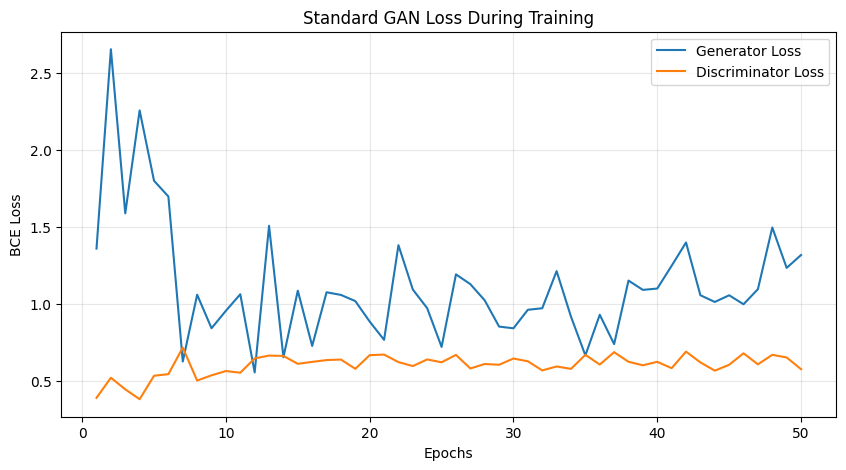

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Define file paths
loss_file = "simple_gan_losses.csv"
output_plot = "simple_gan_loss_plot.png"

print(f"Attempting to plot from {loss_file}...")

try:
    # Read the data from the CSV file
    df = pd.read_csv(loss_file)

    # Create the plot
    plt.figure(figsize=(10, 5))
    plt.plot(df["Epoch"], df["Generator_Loss"], label="Generator Loss")
    plt.plot(df["Epoch"], df["Discriminator_Loss"], label="Discriminator Loss")
    
    plt.title("Standard GAN Loss During Training")
    plt.xlabel("Epochs")
    plt.ylabel("BCE Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Save the plot
    plt.savefig(output_plot)
    print(f"Plot saved successfully to {output_plot}")

except FileNotFoundError:
    print(f"Error: The file '{loss_file}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

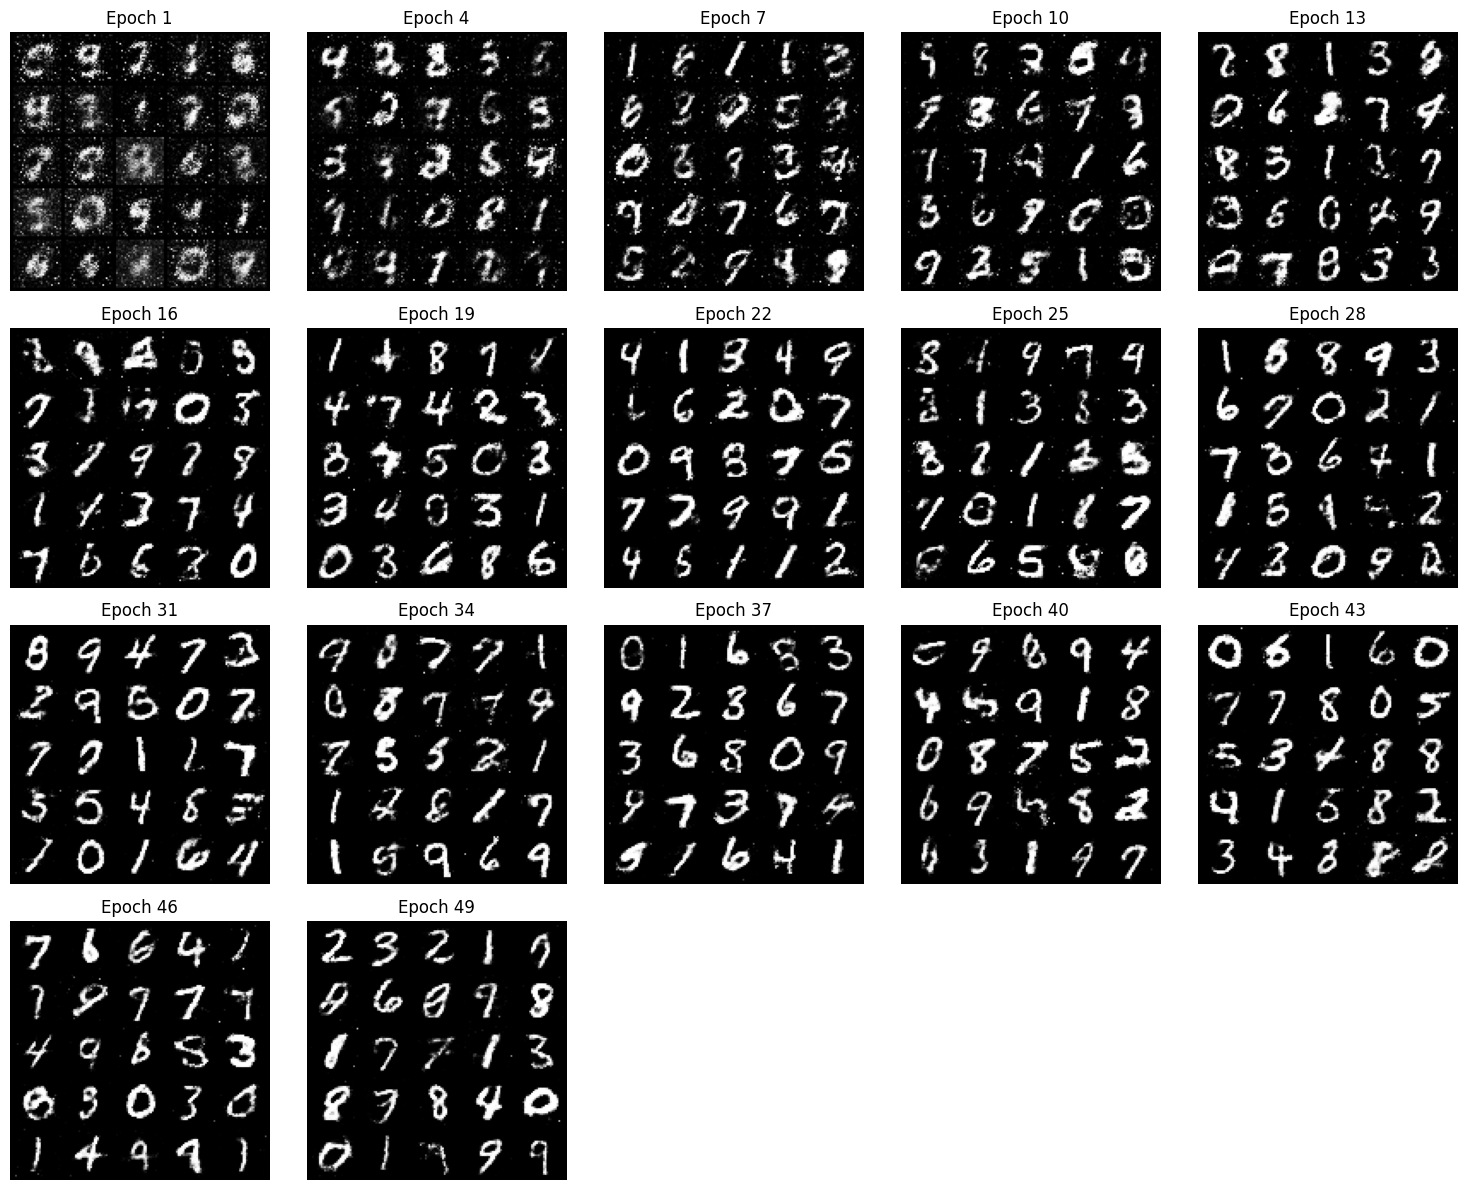

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

folder = "images_gan"
epochs = 50
step = 3

# Collect epochs to display
selected_epochs = list(range(1, epochs+1, step))

# Calculate grid size
cols = 5  # number of images per row
rows = (len(selected_epochs) + cols - 1) // cols

# Prepare the figure
fig, axes = plt.subplots(rows, cols, figsize=(15, rows*3))

for idx, epoch in enumerate(selected_epochs):
    r = idx // cols
    c = idx % cols
    ax = axes[r, c] if rows > 1 else axes[c]

    img_path = os.path.join(folder, f"{epoch}.png")
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(f"Epoch {epoch}")
    ax.axis('off')

# Turn off any empty subplots
for i in range(len(selected_epochs), rows*cols):
    r = i // cols
    c = i % cols
    ax = axes[r, c] if rows > 1 else axes[c]
    ax.axis('off')
plt.tight_layout()
plt.show()